# Map Comparison Benchmark (binary-only)

Compares 4 sensors of varying noise level against a perfect-interpreter reference, using both full-raster pixel-level scoring (`src/map_comparison.py`) and the existing window-based sampling approaches (A–D). Config: `interpreter/experiments/configs/map_comparison_baseline.json`.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('../../src'))

import numpy as np
import pandas as pd

from landscape_stack_collection import LandscapeStackCollection
from map_comparison import (
    perfect_reference_mask,
    pixel_level_metrics,
    pixel_level_metrics_for_collection,
    map_comparison_meta_analysis,
)

In [2]:
PROJ_ROOT = os.path.abspath('../../')

with open('../experiments/configs/map_comparison_baseline.json') as f:
    cfg = json.load(f)

stack_cfg = cfg['landscape_stack_config']
train_exp_cfg = dict(cfg['training_experiment_config'])
val_exp_cfg = dict(cfg['validation_experiment_config'])
train_exp_cfg['patch_dir'] = os.path.join(PROJ_ROOT, train_exp_cfg['patch_dir'])
val_exp_cfg['patch_dir'] = os.path.join(PROJ_ROOT, val_exp_cfg['patch_dir'])

sensor_names = [s['name'] for s in stack_cfg['sensors']]
sensor_names

['Sensor_Clean', 'Sensor_Low', 'Sensor_Medium', 'Sensor_High']

## 1. Training collection + binary classifiers per sensor

In [3]:
train_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=stack_cfg,
    experiment_cfg=train_exp_cfg,
)

bc_cfg = cfg['binary_classifier_config']
train_collection.buildBinaryClassifier(
    sensor_names=bc_cfg['sensor_names'],
    n_strata=bc_cfg['n_strata'],
    samples_per_stratum=bc_cfg['samples_per_stratum'],
    sampling_seed=bc_cfg['sampling_seed'],
    fp_to_fn_ratio=bc_cfg['fp_to_fn_ratio'],
)
train_collection.applyBinaryClassifier(sensor_names=bc_cfg['sensor_names'])

/Users/rkennedy/Dropbox/caol/code/_claudecode/disturbance_uncertainty/src/disturbance_helper_functions.py:31: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-k * (x - x0)))


## 2. Validation collection (20 scenes, disjoint from training)

In [4]:
used_tifs = [s.base_landscape.tif_path for s in train_collection.stacks]

val_collection = LandscapeStackCollection.from_config(
    stack_template_cfg=stack_cfg,
    experiment_cfg=val_exp_cfg,
    exclude_tif_paths=used_tifs,
)

assert set(used_tifs).isdisjoint({s.base_landscape.tif_path for s in val_collection.stacks}), \
    'validation set overlaps training set'

val_collection.loadBinaryModel(train_collection.binary_models)
val_collection.applyBinaryClassifier(sensor_names=bc_cfg['sensor_names'])

/Users/rkennedy/Dropbox/caol/code/_claudecode/disturbance_uncertainty/src/disturbance_helper_functions.py:31: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-k * (x - x0)))


## 0. Validate the perfect-interpreter approximation

The extreme-slope detection/definition curves have no exact no-op (see config `notes`) — confirm empirically that the thresholded perfect-interpreter field agrees with ground truth almost everywhere before trusting it as a scoring reference.

In [5]:
for stack in val_collection.stacks[:3]:
    ref = perfect_reference_mask(stack)
    truth = stack.base_landscape.disturbed.astype(int)
    metrics = pixel_level_metrics(ref, truth)
    print(stack.stack_id, metrics)

DL_839e7ad0 {'agreement': np.float64(1.0), 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'iou': np.float64(1.0), 'n_total': 48240}
DL_0ff4d232 {'agreement': np.float64(1.0), 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'iou': np.float64(1.0), 'n_total': 45225}
DL_94dfc34b {'agreement': np.float64(1.0), 'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1': np.float64(1.0), 'iou': np.float64(1.0), 'n_total': 44844}


## 3. Pixel-level scoring (step 6)

In [6]:
pixel_df = pixel_level_metrics_for_collection(val_collection, sensor_names=bc_cfg['sensor_names'])
pixel_df.groupby('sensor_name')[['agreement', 'precision', 'recall', 'f1', 'iou']].mean()

,agreement,precision,recall,f1,iou
sensor_name,,,,,
Sensor_Clean,0.998576,0.934194,0.991164,0.959868,0.926382
Sensor_High,0.986765,0.714962,0.657087,0.679833,0.517698
Sensor_Low,0.992289,0.819753,0.838262,0.825579,0.707387
Sensor_Medium,0.989652,0.768555,0.757655,0.760457,0.616710


## 4. Window-based sampling (step 7, unmodified A–D)

In [7]:
ws_cfg = cfg['window_sample_config']

window_results = {}
for sensor_name in bc_cfg['sensor_names']:
    result = {}

    # Approaches A/B/C: (map_class, ref_class) schema -> confusion + Olofsson
    for method, window_fn in [
        ('A', val_collection.window_sample_A),
        ('B', val_collection.window_sample_B),
        ('C', val_collection.window_sample_C),
    ]:
        samples = window_fn(sensor_name=sensor_name, **ws_cfg)
        result[f'samples_{method}'] = samples
        result[f'confusion_{method}'] = val_collection.binary_confusion_from_samples(samples)
        result[f'olofsson_{method}'] = val_collection.olofsson_area_estimates(samples, sensor_name=sensor_name)

    # Approach D: (prop_map, prop_interp) scatter, no confusion matrix
    result['samples_D'] = val_collection.window_sample_D(sensor_name=sensor_name, **ws_cfg)

    window_results[sensor_name] = result

{name: {m: r[f'confusion_{m}']['n_ij'] for m in ['A', 'B', 'C']} for name, r in window_results.items()}

{'Sensor_Clean': {'A': array([[17569,     0],
         [   17,   378]]),
  'B': array([[1961,    0],
         [   1,   38]]),
  'C': array([[1961,    0],
         [   1,   38]])},
 'Sensor_Low': {'A': array([[17523,    77],
         [   63,   301]]),
  'B': array([[1954,    0],
         [   7,   39]]),
  'C': array([[1951,    5],
         [   9,   35]])},
 'Sensor_Medium': {'A': array([[17474,    74],
         [   99,   305]]),
  'B': array([[1951,    3],
         [   7,   39]]),
  'C': array([[1951,    5],
         [   9,   35]])},
 'Sensor_High': {'A': array([[17410,   108],
         [  163,   271]]),
  'B': array([[1945,    4],
         [  14,   37]]),
  'C': array([[1942,   10],
         [  18,   30]])}}

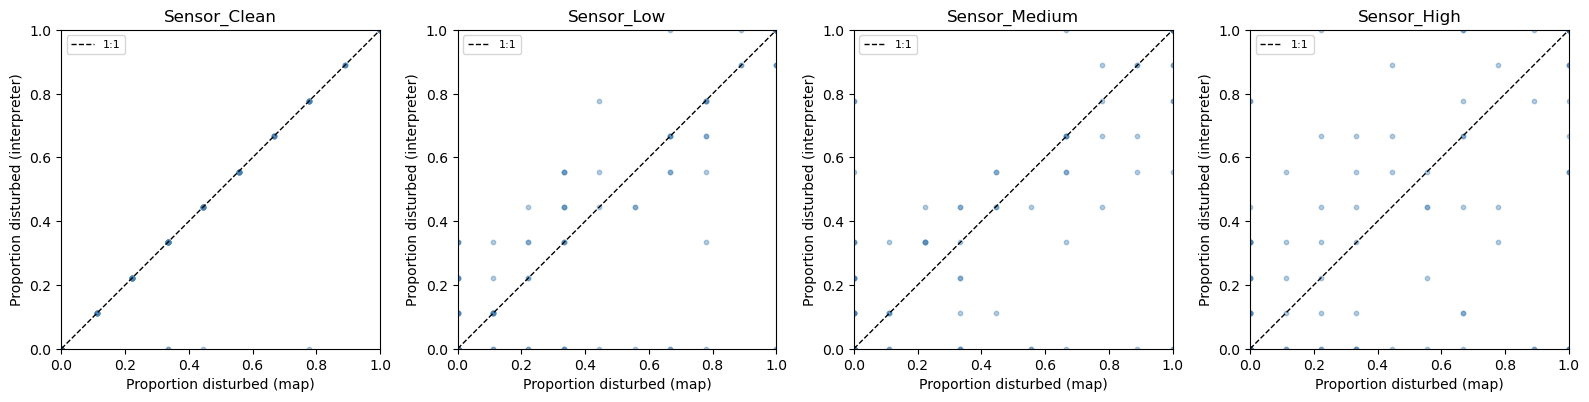

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(bc_cfg['sensor_names']), figsize=(4 * len(bc_cfg['sensor_names']), 4))
for ax, sensor_name in zip(axes, bc_cfg['sensor_names']):
    val_collection.plot_window_D(window_results[sensor_name]['samples_D'], ax=ax, title=sensor_name)
fig.tight_layout()

## 5. Meta-analysis (step 8): pixel-level vs. sampling-based metric deltas

In [9]:
meta_df = map_comparison_meta_analysis(
    val_collection,
    sensor_names=bc_cfg['sensor_names'],
    window_sample_fn=val_collection.window_sample_A,
    window_kwargs=ws_cfg,
)
meta_df

,sensor_a,sensor_b,metric,pixel_delta,sampling_delta
0,Sensor_Clean,Sensor_Low,agreement,0.006287,0.007186
1,Sensor_Clean,Sensor_Low,precision,0.114440,0.177106
2,Sensor_Clean,Sensor_Low,recall,0.152902,0.147757
3,Sensor_Clean,Sensor_Low,f1,0.134289,0.163342
4,Sensor_Clean,Sensor_Low,iou,0.218995,0.272213
5,Sensor_Clean,Sensor_Medium,agreement,0.008924,0.008913
6,Sensor_Clean,Sensor_Medium,precision,0.165639,0.211886
7,Sensor_Clean,Sensor_Medium,recall,0.233509,0.195251
8,Sensor_Clean,Sensor_Medium,f1,0.199412,0.204084
9,Sensor_Clean,Sensor_Medium,iou,0.309672,0.328761
